# MNIST: Smooth vs Non-Smooth Explanations

This experiment measures explanation quality before and after attribution smoothing using:

- Case Align robustness ($S^+$)
- Captum sensitivity (`sensitivity_max`)

It also visualizes smooth vs non-smooth attribution maps with robustness scores.

In [30]:
# Imports, paths, and config
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from captum.attr import IntegratedGradients, DeepLift, NoiseTunnel
from captum.metrics import sensitivity_max
from scipy.stats import pearsonr, spearmanr
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

current_dir = Path.cwd()
if current_dir.name == "experiments":
    SRC_DIR = current_dir.parent
elif (current_dir / "src").exists():
    SRC_DIR = current_dir / "src"
else:
    SRC_DIR = current_dir

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from case_align.metrics import rankdata, safe_normalise_rows
from explainers.lrp import LRP
from train_mnist_model import MNISTNet, set_seed

MODEL_PATH = SRC_DIR / "models" / "mnist" / "mnist_best_model.pt"
ARTIFACT_PATH = SRC_DIR / "explanations" / "mnist" / "mnist_explanations.pt"
DATA_DIR = SRC_DIR / "data"
OUTPUT_DIR = SRC_DIR / "results" / "mnist_smoothing_case_align_sensitivity"

METHODS = None  # None -> use methods from artifact
K = 5
SIM_METRIC = "gower"
PERTURB_RADIUS = 0.1
N_PERTURB_SAMPLES = 10
RETRIEVAL_BATCH_SIZE = 256

# NoiseTunnel settings for the "smooth" variant
NT_TYPE = "smoothgrad"
NT_SAMPLES = 8
NT_STDEVS = 0.1

# Feature-agreement settings (1/3 of MNIST pixels)
FEATURE_TOP_K = (28 * 28) // 3

# Qualitative neighbour-averaged smoothing (same-class nearest neighbours)
LIKE_NEIGHBOUR_K = 5

MAX_QUERY_SAMPLES = None
SEED = 42
VIS_METHOD = "ig"
N_VIS_EXAMPLES = 6

METHOD_LABELS = {"ig": "Integrated Gradients", "dl": "DeepLift", "lrp": "LRP"}

sns.set_theme(style="whitegrid")
print(f"SRC_DIR: {SRC_DIR}")
print(f"Artifact: {ARTIFACT_PATH}")
print(f"Feature top-k: {FEATURE_TOP_K}")
print(f"Qualitative like-neighbour k: {LIKE_NEIGHBOUR_K}")

SRC_DIR: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src
Artifact: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/explanations/mnist/mnist_explanations.pt
Feature top-k: 261
Qualitative like-neighbour k: 5


In [12]:
# Utility functions (Case Align + smoothing + sensitivity)
def _configure_ssl_for_macos() -> None:
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context


def load_model(model_path: Path, device: torch.device) -> MNISTNet:
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    checkpoint = torch.load(model_path, map_location=device)
    model = MNISTNet()
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    elif isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        raise RuntimeError("Unsupported checkpoint format")

    model.to(device)
    model.eval()
    return model


def load_full_test_split(data_dir: Path):
    _configure_ssl_for_macos()
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])

    test_dataset = datasets.MNIST(str(data_dir), train=False, download=True, transform=transform)
    loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

    all_images = []
    all_labels = []
    for images, labels in loader:
        all_images.append(images)
        all_labels.append(labels)

    images_tensor = torch.cat(all_images, dim=0).float()
    labels_np = torch.cat(all_labels, dim=0).numpy().astype(int)
    return images_tensor, labels_np


def predict_labels_for_images(model, images, batch_size, device):
    pred_chunks, conf_chunks = [], []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            end = min(start + batch_size, len(images))
            xb = images[start:end].to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)
            conf, preds = probs.max(dim=1)
            pred_chunks.append(preds.detach().cpu().numpy().astype(int))
            conf_chunks.append(conf.detach().cpu().numpy().astype(float))

    return np.concatenate(pred_chunks, axis=0), np.concatenate(conf_chunks, axis=0)


class MNISTLogitsWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x, return_logits=True)


def build_explainers(model, methods):
    explainers = {}
    logits_model = MNISTLogitsWrapper(model)

    for method in methods:
        if method == "ig":
            explainers[method] = IntegratedGradients(model)
        elif method == "dl":
            explainers[method] = DeepLift(logits_model)
        elif method == "lrp":
            explainers[method] = LRP(logits_model)
        else:
            raise ValueError(f"Unknown method: {method}")

    return explainers


def build_metric_context(matrix, sim_metric, epsilon=1e-8):
    matrix_raw = np.asarray(matrix, dtype=float)
    context = {"matrix_raw": matrix_raw, "epsilon": float(epsilon), "sim_metric_name": sim_metric}

    if sim_metric == "gower":
        ranges = np.ptp(matrix_raw, axis=0)
        context["ranges"] = np.where(ranges == 0, 1.0, ranges)
    elif sim_metric == "cosine":
        context["matrix_repr"] = safe_normalise_rows(matrix_raw, eps=epsilon)
    elif sim_metric == "spearman":
        ranked = np.vstack([rankdata(row) for row in matrix_raw])
        ranked = ranked - ranked.mean(axis=1, keepdims=True)
        context["matrix_repr"] = safe_normalise_rows(ranked, eps=epsilon)
    else:
        raise ValueError(f"Unknown sim_metric: {sim_metric}")

    return context


def row_distances(query_vec, context):
    sim_metric = context["sim_metric_name"]
    epsilon = context["epsilon"]
    matrix_raw = context["matrix_raw"]

    if sim_metric == "gower":
        ranges = context["ranges"]
        dist = np.mean(np.abs(matrix_raw - query_vec[None, :]) / ranges[None, :], axis=1)
        return np.clip(dist, 0.0, 1.0)

    if sim_metric == "cosine":
        matrix_repr = context["matrix_repr"]
        query_repr = safe_normalise_rows(np.asarray(query_vec, dtype=float)[None, :], eps=epsilon)[0]
        similarity = matrix_repr @ query_repr
        return np.clip(1.0 - 0.5 * (similarity + 1.0), 0.0, 1.0)

    if sim_metric == "spearman":
        matrix_repr = context["matrix_repr"]
        q_rank = rankdata(np.asarray(query_vec, dtype=float))
        q_rank = q_rank - q_rank.mean()
        query_repr = safe_normalise_rows(q_rank[None, :], eps=epsilon)[0]
        similarity = matrix_repr @ query_repr
        return np.clip(1.0 - 0.5 * (similarity + 1.0), 0.0, 1.0)

    raise ValueError(f"Unknown sim_metric: {sim_metric}")


def compute_case_align_like_only(query_index, query_label, retrieval_labels, problem_context, solution_context, k, epsilon=1e-8):
    query_problem = problem_context["matrix_raw"][query_index]
    dprob_all = row_distances(query_problem, problem_context)

    like_mask = retrieval_labels == query_label
    like_mask[query_index] = False
    like_indices = np.where(like_mask)[0]
    if like_indices.size == 0:
        return 0.0, 0, False

    like_dists = dprob_all[like_indices]
    order = np.argsort(like_dists)
    k_use = min(k, like_indices.size)
    neigh_indices = like_indices[order[:k_use]]
    dprob_neigh = dprob_all[neigh_indices]

    query_solution = solution_context["matrix_raw"][query_index]
    dsoln_all = row_distances(query_solution, solution_context)
    dsoln_neigh = dsoln_all[neigh_indices]

    ds_min = float(np.min(dsoln_all))
    ds_max = float(np.max(dsoln_all))
    denom = max(ds_max - ds_min, epsilon)
    align = 1.0 - (dsoln_neigh - ds_min) / denom

    weights = 1.0 - dprob_neigh
    weight_sum = float(np.sum(weights))
    if weight_sum <= 0:
        return 0.0, int(k_use), True

    s_plus = float(np.sum(weights * align) / weight_sum)
    return s_plus, int(k_use), True


def gaussian_kernel2d(kernel_size, sigma, device, dtype):
    coords = torch.arange(kernel_size, device=device, dtype=dtype) - (kernel_size - 1) / 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel = torch.outer(g, g)
    kernel = kernel / kernel.sum()
    return kernel.unsqueeze(0).unsqueeze(0)


def smooth_attributions(attrs, sigma=None, kernel_size=5):
    if sigma is None or sigma <= 0:
        return attrs
    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel = gaussian_kernel2d(kernel_size, float(sigma), attrs.device, attrs.dtype)
    channels = attrs.shape[1]
    kernel = kernel.expand(channels, 1, kernel_size, kernel_size)
    return F.conv2d(attrs, kernel, padding=kernel_size // 2, groups=channels)


def compute_retrieval_attributions(explainer, method, images, pred_labels, baseline, batch_size, device, smooth_sigma=None, smooth_kernel_size=5):
    n_total = len(images)
    n_batches = (n_total + batch_size - 1) // batch_size
    chunks = []

    for batch_idx, start in enumerate(range(0, n_total, batch_size), start=1):
        end = min(start + batch_size, n_total)
        xb = images[start:end].to(device).clone().detach().requires_grad_(True)
        targets = torch.from_numpy(pred_labels[start:end]).to(device)

        if method in {"ig", "dl"}:
            b = baseline.to(device).expand_as(xb)
            attrs = explainer.attribute(xb, baselines=b, target=targets)
        else:
            attrs = explainer.attribute(xb, target=targets)

        attrs = smooth_attributions(attrs, sigma=smooth_sigma, kernel_size=smooth_kernel_size)
        chunks.append(attrs.detach().cpu())

        if batch_idx == 1 or batch_idx == n_batches or batch_idx % max(n_batches // 10, 1) == 0:
            print(f"      attribution batches: {batch_idx}/{n_batches}")

    return torch.cat(chunks, dim=0).float()


def compute_sensitivity(explainer, method, image, target, baseline, perturb_radius, n_perturb_samples, device, smooth_sigma=None, smooth_kernel_size=5):
    x = image.unsqueeze(0).to(device)

    if method in {"ig", "dl"}:
        b0 = baseline.to(device)

        def explain_func(inputs, target=None):
            x_in = inputs[0] if isinstance(inputs, tuple) else inputs
            b = b0.expand_as(x_in)
            attrs = explainer.attribute(x_in, baselines=b, target=target)
            return smooth_attributions(attrs, sigma=smooth_sigma, kernel_size=smooth_kernel_size)
    else:
        def explain_func(inputs, target=None):
            x_in = inputs[0] if isinstance(inputs, tuple) else inputs
            attrs = explainer.attribute(x_in, target=target)
            return smooth_attributions(attrs, sigma=smooth_sigma, kernel_size=smooth_kernel_size)

    sens = sensitivity_max(
        explanation_func=explain_func,
        inputs=x,
        target=target,
        perturb_radius=perturb_radius,
        n_perturb_samples=n_perturb_samples,
    )
    return float(sens.detach().cpu().item())


def evaluate_variant(method, variant_name, explainer, query_images, query_labels, query_pred_labels, query_confidences, query_retrieval_indices, retrieval_images, retrieval_labels, retrieval_pred_labels, baseline, k, sim_metric, perturb_radius, n_perturb_samples, retrieval_batch_size, device, smooth_sigma=None, smooth_kernel_size=5):
    n_queries = query_images.shape[0]
    n_retrieval = retrieval_images.shape[0]

    print(f"  [{method}/{variant_name}] building retrieval attributions ({n_retrieval} samples)...")
    retrieval_attributions = compute_retrieval_attributions(
        explainer=explainer,
        method=method,
        images=retrieval_images,
        pred_labels=retrieval_pred_labels,
        baseline=baseline,
        batch_size=retrieval_batch_size,
        device=device,
        smooth_sigma=smooth_sigma,
        smooth_kernel_size=smooth_kernel_size,
    )

    X_flat = retrieval_images.view(n_retrieval, -1).detach().cpu().numpy()
    E_flat = retrieval_attributions.view(n_retrieval, -1).detach().cpu().numpy()

    problem_context = build_metric_context(X_flat, sim_metric=sim_metric)
    solution_context = build_metric_context(E_flat, sim_metric=sim_metric)

    rows = []
    for i in range(n_queries):
        retrieval_index = int(query_retrieval_indices[i])

        s_plus, like_count, has_like_neighbour = compute_case_align_like_only(
            query_index=retrieval_index,
            query_label=int(query_labels[i]),
            retrieval_labels=retrieval_labels,
            problem_context=problem_context,
            solution_context=solution_context,
            k=k,
        )

        sensitivity = compute_sensitivity(
            explainer=explainer,
            method=method,
            image=query_images[i],
            target=int(query_pred_labels[i]),
            baseline=baseline,
            perturb_radius=perturb_radius,
            n_perturb_samples=n_perturb_samples,
            device=device,
            smooth_sigma=smooth_sigma,
            smooth_kernel_size=smooth_kernel_size,
        )

        rows.append({
            "method": method,
            "variant": variant_name,
            "sample_position": int(i),
            "original_test_index": retrieval_index,
            "true_label": int(query_labels[i]),
            "pred_label": int(query_pred_labels[i]),
            "confidence": float(query_confidences[i]),
            "case_align_like_count": int(like_count),
            "case_align_has_like_neighbour": bool(has_like_neighbour),
            "case_align_S_plus": float(s_plus) if has_like_neighbour else np.nan,
            "captum_sensitivity": float(sensitivity),
        })

        if (i + 1) % max(n_queries // 10, 1) == 0 or i == n_queries - 1:
            print(f"      evaluated samples: {i + 1}/{n_queries}")

    query_idx_tensor = torch.from_numpy(query_retrieval_indices.astype(np.int64))
    query_attributions = retrieval_attributions.index_select(0, query_idx_tensor).detach().cpu()
    return pd.DataFrame(rows), query_attributions

In [13]:
# Override smoothing with Captum NoiseTunnel (keeps variant labels raw/smooth for downstream compatibility)
def _attribute_with_optional_noisetunnel(
    explainer,
    method,
    inputs,
    targets,
    baseline,
    nt_samples=None,
    nt_type="smoothgrad",
    nt_stdevs=0.1,
):
    use_nt = nt_samples is not None and int(nt_samples) > 1

    if use_nt:
        nt = NoiseTunnel(explainer)
        if method in {"ig", "dl"}:
            b = baseline.to(inputs.device).expand_as(inputs)
            return nt.attribute(
                inputs,
                nt_type=nt_type,
                nt_samples=int(nt_samples),
                stdevs=float(nt_stdevs),
                baselines=b,
                target=targets,
            )
        return nt.attribute(
            inputs,
            nt_type=nt_type,
            nt_samples=int(nt_samples),
            stdevs=float(nt_stdevs),
            target=targets,
        )

    if method in {"ig", "dl"}:
        b = baseline.to(inputs.device).expand_as(inputs)
        return explainer.attribute(inputs, baselines=b, target=targets)
    return explainer.attribute(inputs, target=targets)


def compute_retrieval_attributions(
    explainer,
    method,
    images,
    pred_labels,
    baseline,
    batch_size,
    device,
    nt_samples=None,
    nt_type="smoothgrad",
    nt_stdevs=0.1,
):
    n_total = len(images)
    n_batches = (n_total + batch_size - 1) // batch_size
    chunks = []

    for batch_idx, start in enumerate(range(0, n_total, batch_size), start=1):
        end = min(start + batch_size, n_total)
        xb = images[start:end].to(device).clone().detach().requires_grad_(True)
        targets = torch.from_numpy(pred_labels[start:end]).to(device)

        attrs = _attribute_with_optional_noisetunnel(
            explainer=explainer,
            method=method,
            inputs=xb,
            targets=targets,
            baseline=baseline,
            nt_samples=nt_samples,
            nt_type=nt_type,
            nt_stdevs=nt_stdevs,
        )
        chunks.append(attrs.detach().cpu())

        if batch_idx == 1 or batch_idx == n_batches or batch_idx % max(n_batches // 10, 1) == 0:
            print(f"      attribution batches: {batch_idx}/{n_batches}")

    return torch.cat(chunks, dim=0).float()


def compute_sensitivity(
    explainer,
    method,
    image,
    target,
    baseline,
    perturb_radius,
    n_perturb_samples,
    device,
    nt_samples=None,
    nt_type="smoothgrad",
    nt_stdevs=0.1,
):
    x = image.unsqueeze(0).to(device)
    use_nt = nt_samples is not None and int(nt_samples) > 1

    if method in {"ig", "dl"}:
        b0 = baseline.to(device)
        if use_nt:
            nt = NoiseTunnel(explainer)

            def explain_func(inputs, target=None):
                x_in = inputs[0] if isinstance(inputs, tuple) else inputs
                b = b0.expand_as(x_in)
                return nt.attribute(
                    x_in,
                    nt_type=nt_type,
                    nt_samples=int(nt_samples),
                    stdevs=float(nt_stdevs),
                    baselines=b,
                    target=target,
                )
        else:
            def explain_func(inputs, target=None):
                x_in = inputs[0] if isinstance(inputs, tuple) else inputs
                b = b0.expand_as(x_in)
                return explainer.attribute(x_in, baselines=b, target=target)
    else:
        if use_nt:
            nt = NoiseTunnel(explainer)

            def explain_func(inputs, target=None):
                x_in = inputs[0] if isinstance(inputs, tuple) else inputs
                return nt.attribute(
                    x_in,
                    nt_type=nt_type,
                    nt_samples=int(nt_samples),
                    stdevs=float(nt_stdevs),
                    target=target,
                )
        else:
            def explain_func(inputs, target=None):
                x_in = inputs[0] if isinstance(inputs, tuple) else inputs
                return explainer.attribute(x_in, target=target)

    sens = sensitivity_max(
        explanation_func=explain_func,
        inputs=x,
        target=target,
        perturb_radius=perturb_radius,
        n_perturb_samples=n_perturb_samples,
    )
    return float(sens.detach().cpu().item())


def evaluate_variant(
    method,
    variant_name,
    explainer,
    query_images,
    query_labels,
    query_pred_labels,
    query_confidences,
    query_retrieval_indices,
    retrieval_images,
    retrieval_labels,
    retrieval_pred_labels,
    baseline,
    k,
    sim_metric,
    perturb_radius,
    n_perturb_samples,
    retrieval_batch_size,
    device,
    nt_samples=None,
    nt_type="smoothgrad",
    nt_stdevs=0.1,
):
    n_queries = query_images.shape[0]
    n_retrieval = retrieval_images.shape[0]

    print(f"  [{method}/{variant_name}] building retrieval attributions ({n_retrieval} samples)...")
    retrieval_attributions = compute_retrieval_attributions(
        explainer=explainer,
        method=method,
        images=retrieval_images,
        pred_labels=retrieval_pred_labels,
        baseline=baseline,
        batch_size=retrieval_batch_size,
        device=device,
        nt_samples=nt_samples,
        nt_type=nt_type,
        nt_stdevs=nt_stdevs,
    )

    X_flat = retrieval_images.view(n_retrieval, -1).detach().cpu().numpy()
    E_flat = retrieval_attributions.view(n_retrieval, -1).detach().cpu().numpy()

    problem_context = build_metric_context(X_flat, sim_metric=sim_metric)
    solution_context = build_metric_context(E_flat, sim_metric=sim_metric)

    rows = []
    for i in range(n_queries):
        retrieval_index = int(query_retrieval_indices[i])

        s_plus, like_count, has_like_neighbour = compute_case_align_like_only(
            query_index=retrieval_index,
            query_label=int(query_labels[i]),
            retrieval_labels=retrieval_labels,
            problem_context=problem_context,
            solution_context=solution_context,
            k=k,
        )

        sensitivity = compute_sensitivity(
            explainer=explainer,
            method=method,
            image=query_images[i],
            target=int(query_pred_labels[i]),
            baseline=baseline,
            perturb_radius=perturb_radius,
            n_perturb_samples=n_perturb_samples,
            device=device,
            nt_samples=nt_samples,
            nt_type=nt_type,
            nt_stdevs=nt_stdevs,
        )

        rows.append({
            "method": method,
            "variant": variant_name,
            "sample_position": int(i),
            "original_test_index": retrieval_index,
            "true_label": int(query_labels[i]),
            "pred_label": int(query_pred_labels[i]),
            "confidence": float(query_confidences[i]),
            "case_align_like_count": int(like_count),
            "case_align_has_like_neighbour": bool(has_like_neighbour),
            "case_align_S_plus": float(s_plus) if has_like_neighbour else np.nan,
            "captum_sensitivity": float(sensitivity),
        })

        if (i + 1) % max(n_queries // 10, 1) == 0 or i == n_queries - 1:
            print(f"      evaluated samples: {i + 1}/{n_queries}")

    query_idx_tensor = torch.from_numpy(query_retrieval_indices.astype(np.int64))
    query_attributions = retrieval_attributions.index_select(0, query_idx_tensor).detach().cpu()
    return pd.DataFrame(rows), query_attributions

In [14]:
# Load model/artifact and retrieval pool
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if not ARTIFACT_PATH.exists():
    raise FileNotFoundError(f"Explanation artifact not found: {ARTIFACT_PATH}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH}")

artifact = torch.load(ARTIFACT_PATH, map_location="cpu")
artifact_methods = [m.lower() for m in artifact.get("methods", ["ig", "dl", "lrp"])]
methods_to_run = artifact_methods if METHODS is None else [m.lower() for m in METHODS]
methods_to_run = [m for m in methods_to_run if m in {"ig", "dl", "lrp"}]
if not methods_to_run:
    raise RuntimeError("No valid methods selected for evaluation.")

query_images = artifact["images"].float()
query_labels = artifact["labels"].numpy().astype(int)
query_pred_labels = artifact["pred_labels"].numpy().astype(int)
query_confidences = artifact["confidences"].numpy().astype(float)
query_retrieval_indices = artifact["sample_indices"].numpy().astype(int)
baseline = artifact["baseline"].float()

if MAX_QUERY_SAMPLES is not None and len(query_images) > MAX_QUERY_SAMPLES:
    query_images = query_images[:MAX_QUERY_SAMPLES]
    query_labels = query_labels[:MAX_QUERY_SAMPLES]
    query_pred_labels = query_pred_labels[:MAX_QUERY_SAMPLES]
    query_confidences = query_confidences[:MAX_QUERY_SAMPLES]
    query_retrieval_indices = query_retrieval_indices[:MAX_QUERY_SAMPLES]

model = load_model(MODEL_PATH, device)
explainers = build_explainers(model, methods_to_run)

print("Loading full MNIST test split for retrieval...")
retrieval_images, retrieval_labels = load_full_test_split(DATA_DIR)
retrieval_pred_labels, _ = predict_labels_for_images(model, retrieval_images, RETRIEVAL_BATCH_SIZE, device)

if np.any(query_retrieval_indices < 0) or np.any(query_retrieval_indices >= len(retrieval_labels)):
    raise IndexError("Some query sample_indices fall outside retrieval pool range.")

print(f"Query samples: {len(query_images)}")
print(f"Retrieval pool size: {len(retrieval_images)}")
print(f"Methods: {methods_to_run}")

Using device: cpu
Loading full MNIST test split for retrieval...
Query samples: 24
Retrieval pool size: 10000
Methods: ['ig', 'dl', 'lrp']


In [15]:
# Evaluate raw vs NoiseTunnel-smoothed explanations
scores_parts = []
query_attr_store = {}

for method in methods_to_run:
    print(f"\n=== Evaluating {METHOD_LABELS.get(method, method.upper())} ===")

    raw_df, raw_query_attr = evaluate_variant(
        method=method,
        variant_name="raw",
        explainer=explainers[method],
        query_images=query_images,
        query_labels=query_labels,
        query_pred_labels=query_pred_labels,
        query_confidences=query_confidences,
        query_retrieval_indices=query_retrieval_indices,
        retrieval_images=retrieval_images,
        retrieval_labels=retrieval_labels,
        retrieval_pred_labels=retrieval_pred_labels,
        baseline=baseline,
        k=K,
        sim_metric=SIM_METRIC,
        perturb_radius=PERTURB_RADIUS,
        n_perturb_samples=N_PERTURB_SAMPLES,
        retrieval_batch_size=RETRIEVAL_BATCH_SIZE,
        device=device,
        nt_samples=None,
        nt_type=NT_TYPE,
        nt_stdevs=NT_STDEVS,
    )

    smooth_df, smooth_query_attr = evaluate_variant(
        method=method,
        variant_name="smooth",
        explainer=explainers[method],
        query_images=query_images,
        query_labels=query_labels,
        query_pred_labels=query_pred_labels,
        query_confidences=query_confidences,
        query_retrieval_indices=query_retrieval_indices,
        retrieval_images=retrieval_images,
        retrieval_labels=retrieval_labels,
        retrieval_pred_labels=retrieval_pred_labels,
        baseline=baseline,
        k=K,
        sim_metric=SIM_METRIC,
        perturb_radius=PERTURB_RADIUS,
        n_perturb_samples=N_PERTURB_SAMPLES,
        retrieval_batch_size=RETRIEVAL_BATCH_SIZE,
        device=device,
        nt_samples=NT_SAMPLES,
        nt_type=NT_TYPE,
        nt_stdevs=NT_STDEVS,
    )

    scores_parts.extend([raw_df, smooth_df])
    query_attr_store[(method, "raw")] = raw_query_attr
    query_attr_store[(method, "smooth")] = smooth_query_attr

scores_df = pd.concat(scores_parts, ignore_index=True)
scores_df["method_label"] = scores_df["method"].map(lambda m: METHOD_LABELS.get(m, m.upper()))

summary_df = (
    scores_df
    .groupby(["method", "variant"], as_index=False)
    .agg(
        n_samples=("sample_position", "count"),
        mean_case_align_S_plus=("case_align_S_plus", "mean"),
        std_case_align_S_plus=("case_align_S_plus", "std"),
        mean_captum_sensitivity=("captum_sensitivity", "mean"),
        std_captum_sensitivity=("captum_sensitivity", "std"),
    )
)
summary_df["method_label"] = summary_df["method"].map(lambda m: METHOD_LABELS.get(m, m.upper()))

corr_rows = []
for (method, variant), group in scores_df.groupby(["method", "variant"]):
    valid = group.dropna(subset=["case_align_S_plus", "captum_sensitivity"])
    if (len(valid) >= 2 and valid["case_align_S_plus"].nunique() > 1 and valid["captum_sensitivity"].nunique() > 1):
        p_r, p_p = pearsonr(valid["case_align_S_plus"], valid["captum_sensitivity"])
        s_r, s_p = spearmanr(valid["case_align_S_plus"], valid["captum_sensitivity"])
    else:
        p_r = p_p = s_r = s_p = np.nan

    corr_rows.append({
        "method": method,
        "variant": variant,
        "pearson_case_align_vs_sensitivity": p_r,
        "pearson_p_value": p_p,
        "spearman_case_align_vs_sensitivity": s_r,
        "spearman_p_value": s_p,
    })

corr_df = pd.DataFrame(corr_rows)

delta_df = scores_df.pivot_table(
    index=["method", "sample_position"],
    columns="variant",
    values=["case_align_S_plus", "captum_sensitivity"],
)
delta_df.columns = [f"{metric}_{variant}" for metric, variant in delta_df.columns]
delta_df = delta_df.reset_index()
delta_df["delta_case_align"] = delta_df["case_align_S_plus_smooth"] - delta_df["case_align_S_plus_raw"]
delta_df["delta_sensitivity"] = delta_df["captum_sensitivity_smooth"] - delta_df["captum_sensitivity_raw"]

print("Evaluation complete.")
print(summary_df[["method_label", "variant", "mean_case_align_S_plus", "mean_captum_sensitivity"]].round(4).to_string(index=False))


=== Evaluating Integrated Gradients ===
  [ig/raw] building retrieval attributions (10000 samples)...
      attribution batches: 1/40
      attribution batches: 4/40
      attribution batches: 8/40
      attribution batches: 12/40
      attribution batches: 16/40
      attribution batches: 20/40
      attribution batches: 24/40
      attribution batches: 28/40
      attribution batches: 32/40
      attribution batches: 36/40
      attribution batches: 40/40
      evaluated samples: 2/24
      evaluated samples: 4/24
      evaluated samples: 6/24
      evaluated samples: 8/24
      evaluated samples: 10/24
      evaluated samples: 12/24
      evaluated samples: 14/24
      evaluated samples: 16/24
      evaluated samples: 18/24
      evaluated samples: 20/24
      evaluated samples: 22/24
      evaluated samples: 24/24
  [ig/smooth] building retrieval attributions (10000 samples)...
      attribution batches: 1/40
      attribution batches: 4/40
      attribution batches: 8/40
      at

/Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/agree-iccbr/lib/python3.11/site-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


      attribution batches: 1/40
      attribution batches: 4/40
      attribution batches: 8/40
      attribution batches: 12/40
      attribution batches: 16/40
      attribution batches: 20/40
      attribution batches: 24/40
      attribution batches: 28/40
      attribution batches: 32/40
      attribution batches: 36/40
      attribution batches: 40/40


/Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/agree-iccbr/lib/python3.11/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


      evaluated samples: 2/24
      evaluated samples: 4/24
      evaluated samples: 6/24
      evaluated samples: 8/24
      evaluated samples: 10/24
      evaluated samples: 12/24
      evaluated samples: 14/24
      evaluated samples: 16/24
      evaluated samples: 18/24
      evaluated samples: 20/24
      evaluated samples: 22/24
      evaluated samples: 24/24
  [dl/smooth] building retrieval attributions (10000 samples)...


/Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/agree-iccbr/lib/python3.11/site-packages/captum/attr/_core/noise_tunnel.py:401: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = attr_func.__wrapped__(  # type: ignore


      attribution batches: 1/40
      attribution batches: 4/40
      attribution batches: 8/40
      attribution batches: 12/40
      attribution batches: 16/40
      attribution batches: 20/40
      attribution batches: 24/40
      attribution batches: 28/40
      attribution batches: 32/40
      attribution batches: 36/40
      attribution batches: 40/40
      evaluated samples: 2/24
      evaluated samples: 4/24
      evaluated samples: 6/24
      evaluated samples: 8/24
      evaluated samples: 10/24
      evaluated samples: 12/24
      evaluated samples: 14/24
      evaluated samples: 16/24
      evaluated samples: 18/24
      evaluated samples: 20/24
      evaluated samples: 22/24
      evaluated samples: 24/24

=== Evaluating LRP ===
  [lrp/raw] building retrieval attributions (10000 samples)...
      attribution batches: 1/40
      attribution batches: 4/40
      attribution batches: 8/40
      attribution batches: 12/40
      attribution batches: 16/40
      attribution batch

/Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/explainers/lrp.py:202: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs)


      evaluated samples: 2/24
      evaluated samples: 4/24
      evaluated samples: 6/24
      evaluated samples: 8/24
      evaluated samples: 10/24
      evaluated samples: 12/24
      evaluated samples: 14/24
      evaluated samples: 16/24
      evaluated samples: 18/24
      evaluated samples: 20/24
      evaluated samples: 22/24
      evaluated samples: 24/24
  [lrp/smooth] building retrieval attributions (10000 samples)...
      attribution batches: 1/40
      attribution batches: 4/40
      attribution batches: 8/40
      attribution batches: 12/40
      attribution batches: 16/40
      attribution batches: 20/40
      attribution batches: 24/40
      attribution batches: 28/40
      attribution batches: 32/40
      attribution batches: 36/40
      attribution batches: 40/40
      evaluated samples: 2/24
      evaluated samples: 4/24
      evaluated samples: 6/24
      evaluated samples: 8/24
      evaluated samples: 10/24
      evaluated samples: 12/24
      evaluated samples:

In [26]:
# Feature agreement (top-k overlap) across explainer pairs
if len(methods_to_run) < 2:
    raise RuntimeError("Feature agreement requires at least two explainers in methods_to_run.")


def _topk_feature_indices(attr_map: np.ndarray, top_k: int) -> np.ndarray:
    flat = np.abs(attr_map.reshape(-1))
    k_use = min(int(top_k), flat.shape[0])
    if k_use <= 0:
        raise ValueError("top_k must be >= 1")
    if k_use == flat.shape[0]:
        return np.arange(flat.shape[0], dtype=np.int64)
    return np.argpartition(flat, -k_use)[-k_use:]


pair_rows = []
for variant in ["raw", "smooth"]:
    for sample_pos in range(len(query_images)):
        topk_cache = {}
        for method in methods_to_run:
            attr_map = query_attr_store[(method, variant)][sample_pos, 0].detach().cpu().numpy()
            topk_cache[method] = _topk_feature_indices(attr_map, FEATURE_TOP_K)

        for i in range(len(methods_to_run)):
            for j in range(i + 1, len(methods_to_run)):
                method_a = methods_to_run[i]
                method_b = methods_to_run[j]

                idx_a = topk_cache[method_a]
                idx_b = topk_cache[method_b]

                intersection = np.intersect1d(idx_a, idx_b, assume_unique=False).size
                union = np.union1d(idx_a, idx_b).size

                pair_rows.append({
                    "variant": variant,
                    "sample_position": int(sample_pos),
                    "method_a": method_a,
                    "method_b": method_b,
                    "method_pair": f"{method_a}-{method_b}",
                    "method_pair_label": f"{METHOD_LABELS.get(method_a, method_a.upper())} vs {METHOD_LABELS.get(method_b, method_b.upper())}",
                    "top_k": int(min(FEATURE_TOP_K, idx_a.size, idx_b.size)),
                    "intersection_size": int(intersection),
                    "union_size": int(union),
                    "feature_overlap_at_k": float(intersection / max(min(idx_a.size, idx_b.size), 1)),
                    "feature_agreement_jaccard": float(intersection / max(union, 1)),
                })

feature_agreement_df = pd.DataFrame(pair_rows)

feature_agreement_summary_df = (
    feature_agreement_df
    .groupby(["variant", "method_pair", "method_pair_label"], as_index=False)
    .agg(
        n_samples=("sample_position", "count"),
        top_k=("top_k", "first"),
        mean_feature_overlap_at_k=("feature_overlap_at_k", "mean"),
        std_feature_overlap_at_k=("feature_overlap_at_k", "std"),
        mean_feature_agreement_jaccard=("feature_agreement_jaccard", "mean"),
        std_feature_agreement_jaccard=("feature_agreement_jaccard", "std"),
    )
)

feature_agreement_variant_summary_df = (
    feature_agreement_df
    .groupby(["variant"], as_index=False)
    .agg(
        mean_feature_overlap_at_k=("feature_overlap_at_k", "mean"),
        std_feature_overlap_at_k=("feature_overlap_at_k", "std"),
        mean_feature_agreement_jaccard=("feature_agreement_jaccard", "mean"),
        std_feature_agreement_jaccard=("feature_agreement_jaccard", "std"),
    )
)

print(f"Feature agreement computed using top-k={FEATURE_TOP_K} features.")
print("\nBy variant:")
print(feature_agreement_variant_summary_df.round(4).to_string(index=False))
print("\nBy explainer pair and variant:")
print(
    feature_agreement_summary_df[
        [
            "variant",
            "method_pair_label",
            "mean_feature_overlap_at_k",
            "mean_feature_agreement_jaccard",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

Feature agreement computed using top-k=261 features.

By variant:
variant  mean_feature_overlap_at_k  std_feature_overlap_at_k  mean_feature_agreement_jaccard  std_feature_agreement_jaccard
    raw                     0.8055                    0.1346                          0.6967                         0.2016
 smooth                     0.7692                    0.0682                          0.6299                         0.0907

By explainer pair and variant:
variant                method_pair_label  mean_feature_overlap_at_k  mean_feature_agreement_jaccard
    raw                  DeepLift vs LRP                     0.9850                          0.9705
    raw Integrated Gradients vs DeepLift                     0.7160                          0.5601
    raw      Integrated Gradients vs LRP                     0.7155                          0.5595
 smooth                  DeepLift vs LRP                     0.8490                          0.7381
 smooth Integrated Gradients v

/var/folders/wc/1h7jfddj0vg_39q37rx0sg7r0000gn/T/ipykernel_35599/1490911023.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/var/folders/wc/1h7jfddj0vg_39q37rx0sg7r0000gn/T/ipykernel_35599/1490911023.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


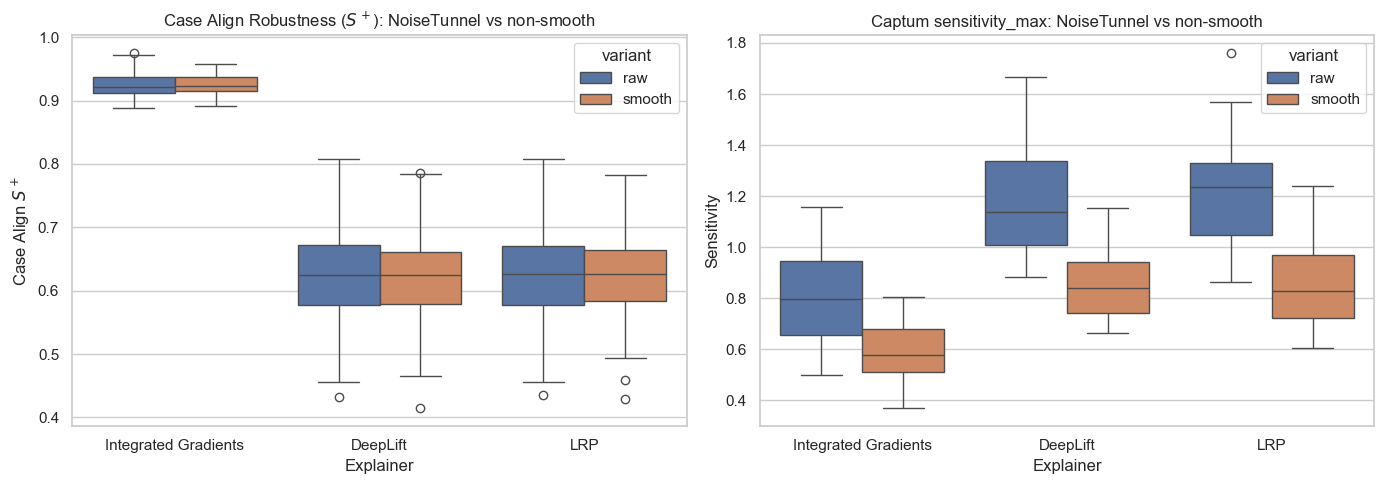

/var/folders/wc/1h7jfddj0vg_39q37rx0sg7r0000gn/T/ipykernel_35599/1490911023.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Δ Case Align", "Δ Sensitivity"])


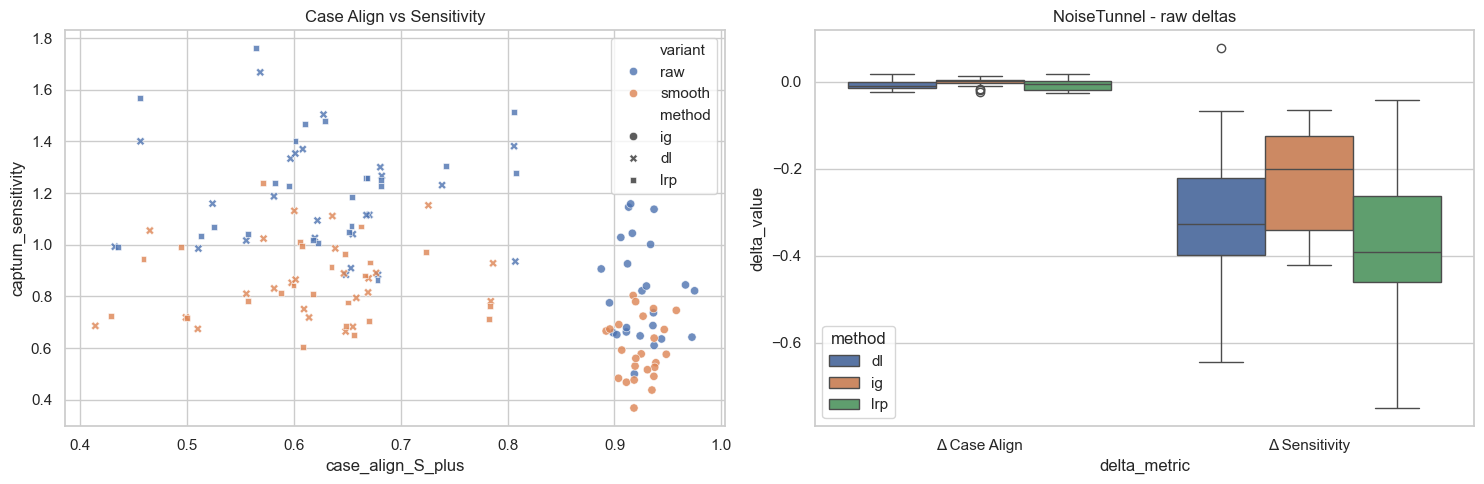

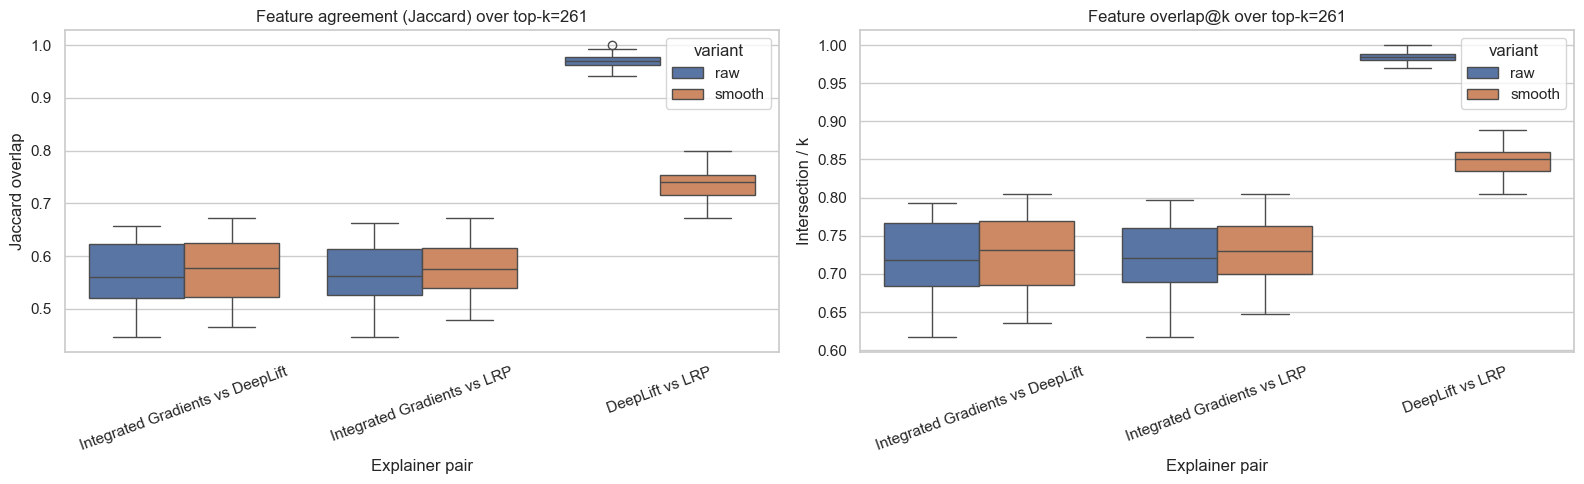

In [27]:
# Quantitative visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=scores_df, x="method", y="case_align_S_plus", hue="variant", order=methods_to_run, ax=axes[0])
axes[0].set_title("Case Align Robustness ($S^+$): NoiseTunnel vs non-smooth")
axes[0].set_xlabel("Explainer")
axes[0].set_ylabel("Case Align $S^+$")

sns.boxplot(data=scores_df, x="method", y="captum_sensitivity", hue="variant", order=methods_to_run, ax=axes[1])
axes[1].set_title("Captum sensitivity_max: NoiseTunnel vs non-smooth")
axes[1].set_xlabel("Explainer")
axes[1].set_ylabel("Sensitivity")

for ax in axes:
    ax.set_xticklabels([METHOD_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=scores_df, x="case_align_S_plus", y="captum_sensitivity", hue="variant", style="method", alpha=0.8, ax=axes[0])
axes[0].set_title("Case Align vs Sensitivity")

delta_long = delta_df.melt(id_vars=["method", "sample_position"], value_vars=["delta_case_align", "delta_sensitivity"], var_name="delta_metric", value_name="delta_value")
sns.boxplot(data=delta_long, x="delta_metric", y="delta_value", hue="method", ax=axes[1])
axes[1].set_title("NoiseTunnel - raw deltas")
axes[1].set_xticklabels(["Δ Case Align", "Δ Sensitivity"])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=feature_agreement_df, x="method_pair_label", y="feature_agreement_jaccard", hue="variant", ax=axes[0])
axes[0].set_title(f"Feature agreement (Jaccard) over top-k={FEATURE_TOP_K}")
axes[0].set_xlabel("Explainer pair")
axes[0].set_ylabel("Jaccard overlap")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=feature_agreement_df, x="method_pair_label", y="feature_overlap_at_k", hue="variant", ax=axes[1])
axes[1].set_title(f"Feature overlap@k over top-k={FEATURE_TOP_K}")
axes[1].set_xlabel("Explainer pair")
axes[1].set_ylabel("Intersection / k")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

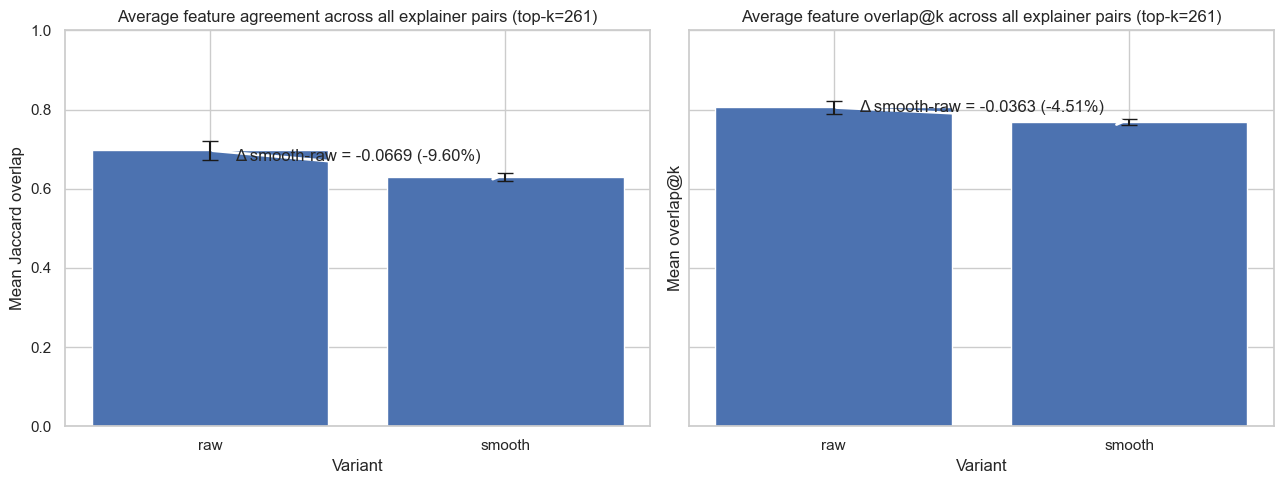

Aggregate agreement (all explainer pairs combined):
raw mean Jaccard:       0.6967
smooth mean Jaccard:    0.6299
Δ Jaccard smooth-raw:   -0.0669 (-9.60%)
raw mean overlap@k:     0.8055
smooth mean overlap@k:  0.7692
Δ overlap@k smooth-raw: -0.0363 (-4.51%)


In [28]:
# Aggregate feature agreement change (all explainer pairs combined)
variant_agreement = feature_agreement_df.groupby("variant", as_index=False).agg(
    mean_jaccard=("feature_agreement_jaccard", "mean"),
    std_jaccard=("feature_agreement_jaccard", "std"),
    n_jaccard=("feature_agreement_jaccard", "count"),
    mean_overlap_at_k=("feature_overlap_at_k", "mean"),
    std_overlap_at_k=("feature_overlap_at_k", "std"),
    n_overlap_at_k=("feature_overlap_at_k", "count"),
)
variant_agreement["sem_jaccard"] = variant_agreement["std_jaccard"] / np.sqrt(variant_agreement["n_jaccard"].clip(lower=1))
variant_agreement["sem_overlap_at_k"] = variant_agreement["std_overlap_at_k"] / np.sqrt(variant_agreement["n_overlap_at_k"].clip(lower=1))
variant_agreement = variant_agreement.set_index("variant")

if not {"raw", "smooth"}.issubset(variant_agreement.index):
    raise RuntimeError("Expected both raw and smooth variants for aggregate agreement plot.")


def _plot_variant_delta(ax, raw_mean, smooth_mean, raw_sem, smooth_sem, ylabel, title):
    x = np.array([0, 1], dtype=float)
    y = np.array([raw_mean, smooth_mean], dtype=float)
    yerr = np.array([raw_sem, smooth_sem], dtype=float)
    delta = smooth_mean - raw_mean
    delta_pct = (delta / raw_mean * 100.0) if raw_mean != 0 else np.nan

    ax.bar(["raw", "smooth"], y, yerr=yerr, capsize=6)
    ax.set_title(title)
    ax.set_xlabel("Variant")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)

    ax.annotate("", xy=(x[1], y[1]), xytext=(x[0], y[0]), arrowprops=dict(arrowstyle="->", lw=2))
    ax.text(
        x=0.5,
        y=(y[0] + y[1]) / 2,
        s=f"Δ smooth-raw = {delta:+.4f} ({delta_pct:+.2f}%)",
        ha="center",
        va="bottom",
    )

    return delta, delta_pct


raw_mean_j = float(variant_agreement.loc["raw", "mean_jaccard"])
smooth_mean_j = float(variant_agreement.loc["smooth", "mean_jaccard"])
raw_sem_j = float(variant_agreement.loc["raw", "sem_jaccard"])
smooth_sem_j = float(variant_agreement.loc["smooth", "sem_jaccard"])

raw_mean_k = float(variant_agreement.loc["raw", "mean_overlap_at_k"])
smooth_mean_k = float(variant_agreement.loc["smooth", "mean_overlap_at_k"])
raw_sem_k = float(variant_agreement.loc["raw", "sem_overlap_at_k"])
smooth_sem_k = float(variant_agreement.loc["smooth", "sem_overlap_at_k"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

delta_j, delta_j_pct = _plot_variant_delta(
    axes[0],
    raw_mean=raw_mean_j,
    smooth_mean=smooth_mean_j,
    raw_sem=raw_sem_j,
    smooth_sem=smooth_sem_j,
    ylabel="Mean Jaccard overlap",
    title=f"Average feature agreement across all explainer pairs (top-k={FEATURE_TOP_K})",
)

delta_k, delta_k_pct = _plot_variant_delta(
    axes[1],
    raw_mean=raw_mean_k,
    smooth_mean=smooth_mean_k,
    raw_sem=raw_sem_k,
    smooth_sem=smooth_sem_k,
    ylabel="Mean overlap@k",
    title=f"Average feature overlap@k across all explainer pairs (top-k={FEATURE_TOP_K})",
)

plt.tight_layout()
plt.show()

print("Aggregate agreement (all explainer pairs combined):")
print(f"raw mean Jaccard:       {raw_mean_j:.4f}")
print(f"smooth mean Jaccard:    {smooth_mean_j:.4f}")
print(f"Δ Jaccard smooth-raw:   {delta_j:+.4f} ({delta_j_pct:+.2f}%)")
print(f"raw mean overlap@k:     {raw_mean_k:.4f}")
print(f"smooth mean overlap@k:  {smooth_mean_k:.4f}")
print(f"Δ overlap@k smooth-raw: {delta_k:+.4f} ({delta_k_pct:+.2f}%)")

Top-6 examples by |Δ robustness| for Integrated Gradients:
                 case_align_S_plus_raw  case_align_S_plus_smooth  \
sample_position                                                    
20                              0.9726                    0.9485   
15                              0.9665                    0.9466   
1                               0.9750                    0.9579   
4                               0.9133                    0.9268   
12                              0.9440                    0.9351   
8                               0.8988                    0.9068   

                 captum_sensitivity_raw  captum_sensitivity_smooth  \
sample_position                                                      
20                               0.6424                     0.5761   
15                               0.8446                     0.6720   
1                                0.8218                     0.7461   
4                                1.1458       

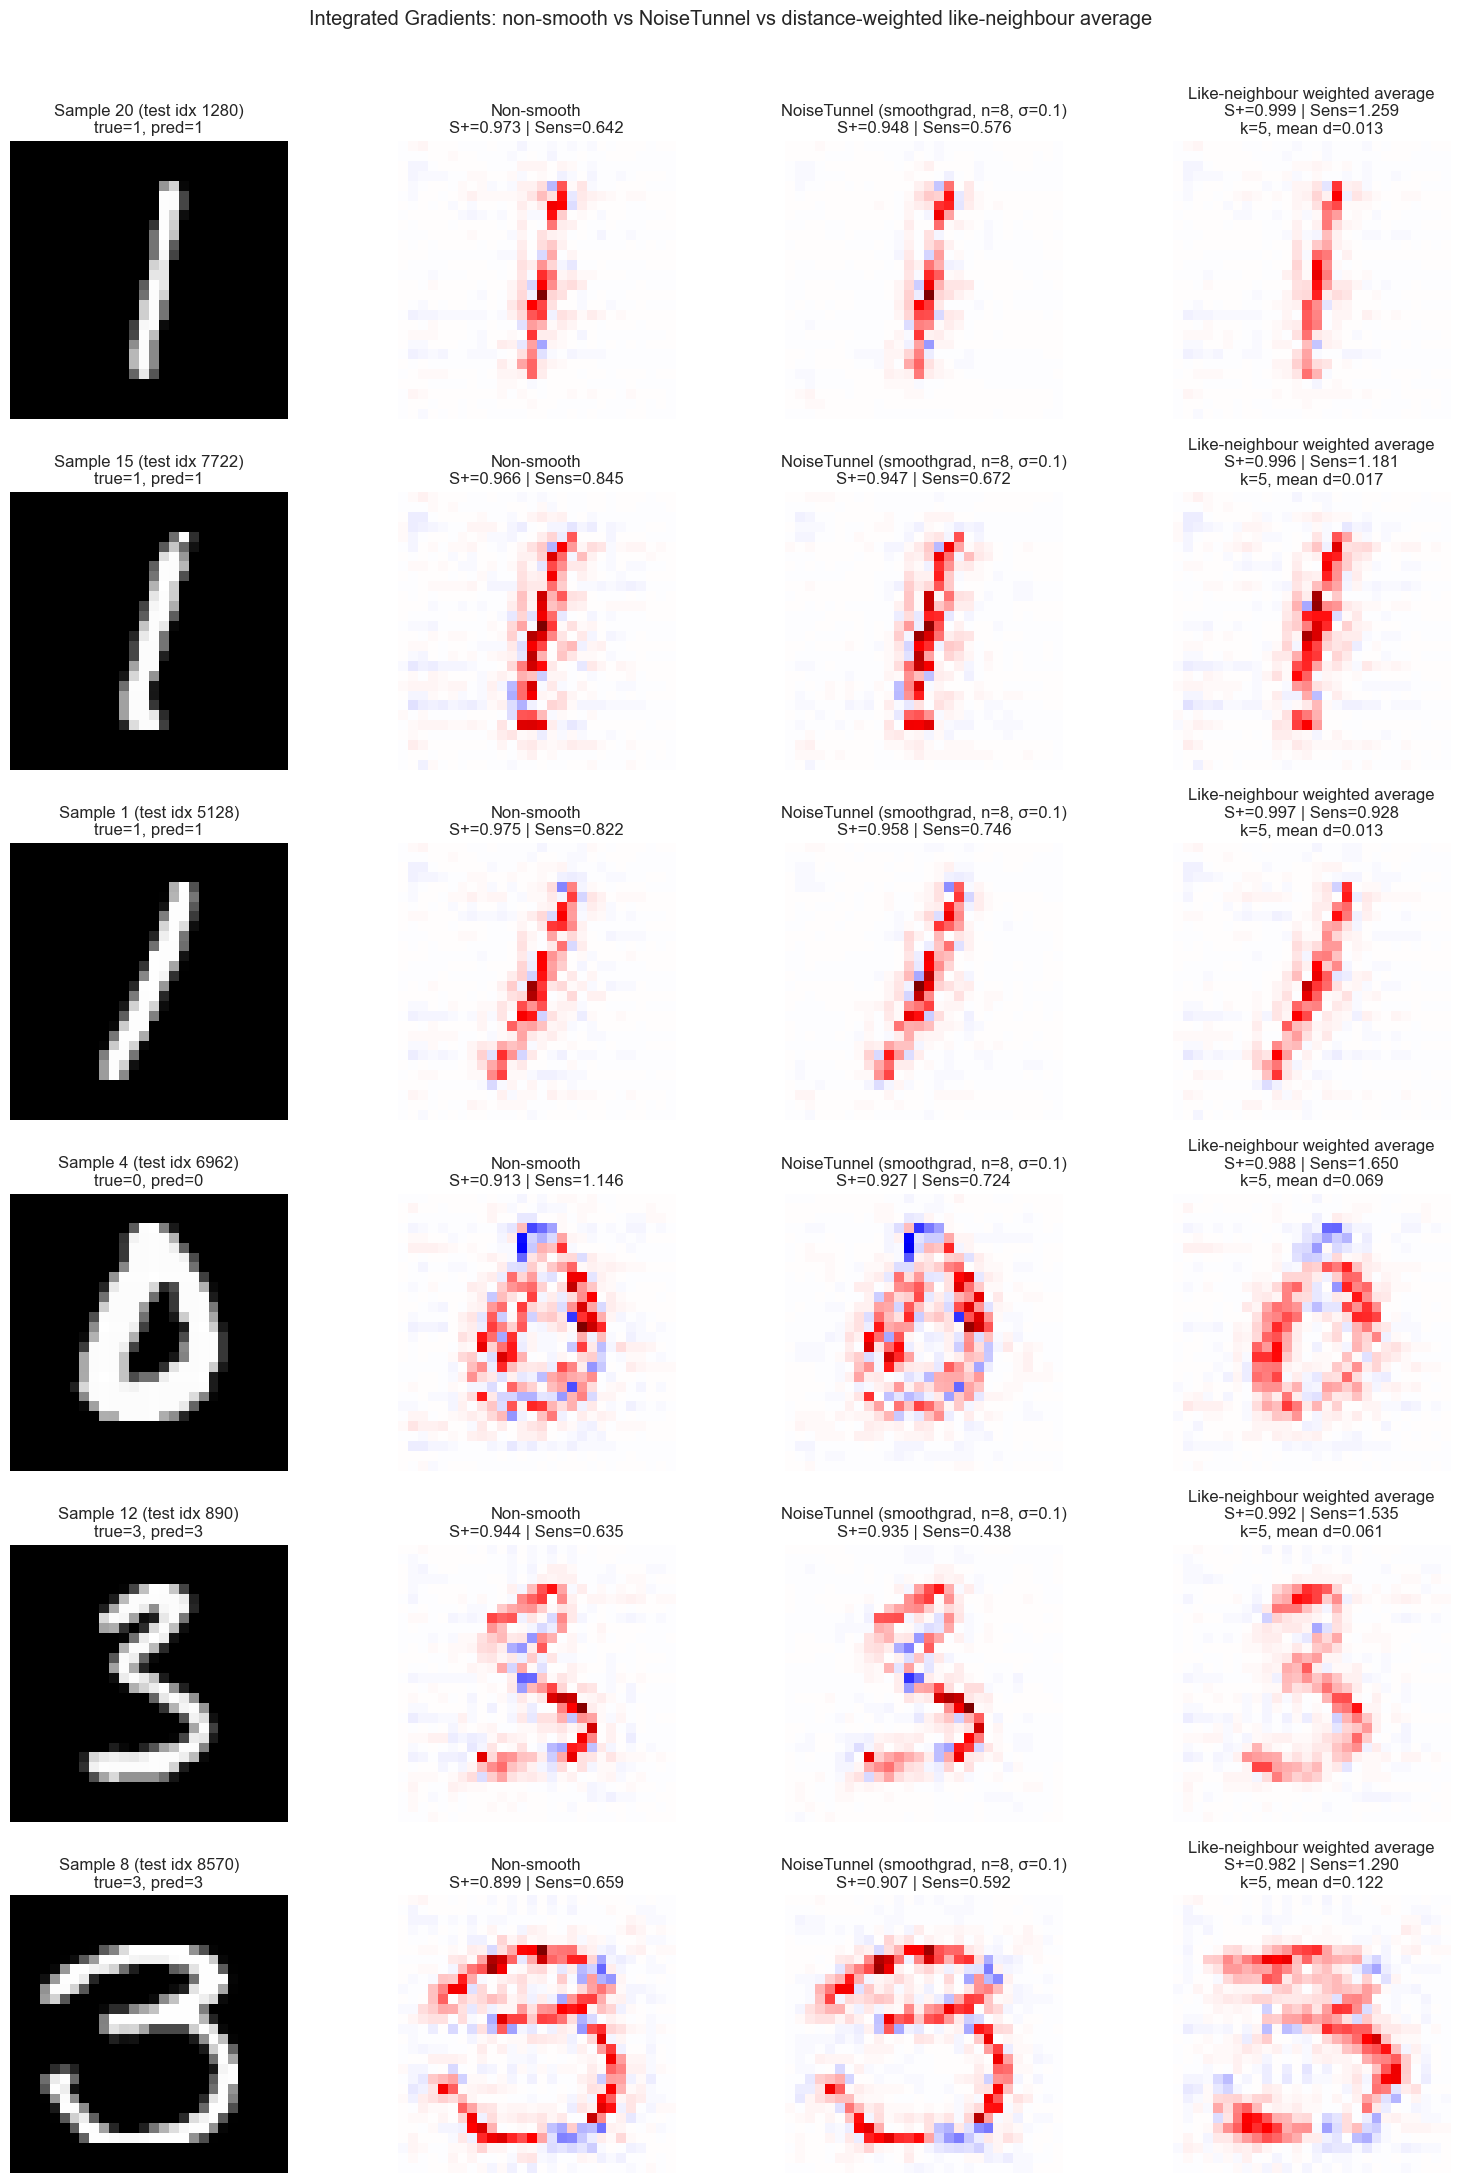

In [35]:
# Qualitative visualization: NoiseTunnel-smoothed, like-neighbour-averaged, and non-smooth examples
if VIS_METHOD not in methods_to_run:
    raise ValueError(f"VIS_METHOD={VIS_METHOD} not in selected methods {methods_to_run}")

method_scores = scores_df[scores_df["method"] == VIS_METHOD].copy()
method_pivot = method_scores.pivot(index="sample_position", columns="variant", values=["case_align_S_plus", "captum_sensitivity"])
method_pivot.columns = [f"{metric}_{variant}" for metric, variant in method_pivot.columns]

method_pivot["abs_delta_robustness"] = (method_pivot["case_align_S_plus_smooth"] - method_pivot["case_align_S_plus_raw"]).abs()
selected_positions = method_pivot.sort_values("abs_delta_robustness", ascending=False).head(N_VIS_EXAMPLES).index.tolist()

print(f"Top-{len(selected_positions)} examples by |Δ robustness| for {METHOD_LABELS.get(VIS_METHOD, VIS_METHOD.upper())}:")
print(method_pivot.loc[selected_positions, ["case_align_S_plus_raw", "case_align_S_plus_smooth", "captum_sensitivity_raw", "captum_sensitivity_smooth", "abs_delta_robustness"]].round(4))

raw_attrs = query_attr_store[(VIS_METHOD, "raw")].numpy()
smooth_attrs = query_attr_store[(VIS_METHOD, "smooth")].numpy()

# Build nearest like-neighbour sets in problem space (same class)
X_flat = retrieval_images.view(len(retrieval_images), -1).detach().cpu().numpy()
problem_context = build_metric_context(X_flat, sim_metric=SIM_METRIC)

# Cache retrieval raw attributions for selected visualization method
if "qual_retrieval_raw_attr_cache" not in globals():
    qual_retrieval_raw_attr_cache = {}

if VIS_METHOD not in qual_retrieval_raw_attr_cache:
    print(f"Computing retrieval raw attributions for {VIS_METHOD} (for like-neighbour S+ and sensitivity)...")
    qual_retrieval_raw_attr_cache[VIS_METHOD] = compute_retrieval_attributions(
        explainer=explainers[VIS_METHOD],
        method=VIS_METHOD,
        images=retrieval_images,
        pred_labels=retrieval_pred_labels,
        baseline=baseline,
        batch_size=RETRIEVAL_BATCH_SIZE,
        device=device,
        nt_samples=None,
        nt_type=NT_TYPE,
        nt_stdevs=NT_STDEVS,
    )

retrieval_raw_attrs = qual_retrieval_raw_attr_cache[VIS_METHOD]
retrieval_raw_attrs_np = retrieval_raw_attrs.detach().cpu().numpy()
retrieval_raw_flat = retrieval_raw_attrs.view(len(retrieval_images), -1).detach().cpu().numpy()
solution_context_raw = build_metric_context(retrieval_raw_flat, sim_metric=SIM_METRIC)


def _distance_weighted_average(attr_array, neighbour_distances, eps=1e-8):
    distances = np.asarray(neighbour_distances, dtype=float).reshape(-1)
    if attr_array.shape[0] != distances.shape[0]:
        raise ValueError("attr_array and neighbour_distances must have matching first dimension")

    distances = np.maximum(distances, eps)
    weights = 1.0 / distances
    if (not np.all(np.isfinite(weights))) or float(np.sum(weights)) <= 0.0:
        weights = np.ones_like(distances, dtype=float)
    weights = weights / np.sum(weights)

    return np.tensordot(weights, attr_array, axes=(0, 0))


def _case_align_s_plus_for_solution(query_problem_vec, query_solution_vec, query_label, exclude_retrieval_index=None):
    dprob_all = row_distances(query_problem_vec, problem_context)

    like_mask = retrieval_labels == int(query_label)
    if exclude_retrieval_index is not None and 0 <= int(exclude_retrieval_index) < len(retrieval_labels):
        like_mask[int(exclude_retrieval_index)] = False
    like_indices = np.where(like_mask)[0]

    if like_indices.size == 0:
        return np.nan

    like_dists = dprob_all[like_indices]
    order = np.argsort(like_dists)
    k_use = min(int(K), like_indices.size)
    neigh_indices = like_indices[order[:k_use]]

    dprob_neigh = dprob_all[neigh_indices]
    dsoln_all = row_distances(query_solution_vec, solution_context_raw)
    dsoln_neigh = dsoln_all[neigh_indices]

    ds_min = float(np.min(dsoln_all))
    ds_max = float(np.max(dsoln_all))
    denom = max(ds_max - ds_min, 1e-8)
    align = 1.0 - (dsoln_neigh - ds_min) / denom

    weights = 1.0 - dprob_neigh
    weight_sum = float(np.sum(weights))
    if weight_sum <= 0:
        return 0.0
    return float(np.sum(weights * align) / weight_sum)


def _knn_weighted_attr_from_batch(x_batch, like_label, k):
    like_indices = np.where(retrieval_labels == int(like_label))[0]
    x_flat = x_batch.detach().cpu().numpy().reshape(x_batch.shape[0], -1)
    out = []

    for x_vec in x_flat:
        dprob_all = row_distances(x_vec, problem_context)

        if like_indices.size > 0:
            like_dists = dprob_all[like_indices]
            order = np.argsort(like_dists)
            k_use = min(int(k), like_indices.size)
            top_idx = order[:k_use]
            neigh_indices = like_indices[top_idx]
            neigh_distances = like_dists[top_idx]
        else:
            nearest_idx = int(np.argmin(dprob_all))
            neigh_indices = np.array([nearest_idx], dtype=np.int64)
            neigh_distances = np.array([max(float(dprob_all[nearest_idx]), 1e-8)], dtype=float)

        weighted_attr = _distance_weighted_average(retrieval_raw_attrs_np[neigh_indices], neigh_distances)
        out.append(weighted_attr)

    out_np = np.stack(out, axis=0)
    return torch.from_numpy(out_np).to(x_batch.device, dtype=x_batch.dtype)


like_neighbour_indices_by_sample = {}
like_neighbour_distances_by_sample = {}
knn_avg_attrs = {}
knn_metrics_rows = []

for sample_pos in selected_positions:
    retrieval_index = int(query_retrieval_indices[sample_pos])
    query_label = int(query_labels[sample_pos])

    query_problem = problem_context["matrix_raw"][retrieval_index]
    dprob_all = row_distances(query_problem, problem_context)

    like_mask = retrieval_labels == query_label
    like_mask[retrieval_index] = False
    like_indices = np.where(like_mask)[0]

    if like_indices.size == 0:
        neighbour_indices = np.array([retrieval_index], dtype=np.int64)
        neighbour_distances = np.array([max(float(dprob_all[retrieval_index]), 1e-8)], dtype=float)
    else:
        like_dists = dprob_all[like_indices]
        order = np.argsort(like_dists)
        k_use = min(int(LIKE_NEIGHBOUR_K), like_indices.size)
        top_idx = order[:k_use]
        neighbour_indices = like_indices[top_idx].astype(np.int64)
        neighbour_distances = like_dists[top_idx].astype(float)

    like_neighbour_indices_by_sample[int(sample_pos)] = neighbour_indices
    like_neighbour_distances_by_sample[int(sample_pos)] = neighbour_distances

    knn_attr = _distance_weighted_average(retrieval_raw_attrs_np[neighbour_indices], neighbour_distances)
    knn_avg_attrs[int(sample_pos)] = knn_attr

    knn_s_plus = _case_align_s_plus_for_solution(
        query_problem_vec=query_problem,
        query_solution_vec=knn_attr.reshape(-1),
        query_label=query_label,
        exclude_retrieval_index=retrieval_index,
    )

    x0 = query_images[sample_pos].unsqueeze(0).to(device)
    pred_target = int(query_pred_labels[sample_pos])

    def _knn_explain_func(inputs, target=None, like_label=query_label):
        x_in = inputs[0] if isinstance(inputs, tuple) else inputs
        return _knn_weighted_attr_from_batch(x_in, like_label=like_label, k=LIKE_NEIGHBOUR_K)

    knn_sensitivity = sensitivity_max(
        explanation_func=_knn_explain_func,
        inputs=x0,
        target=pred_target,
        perturb_radius=PERTURB_RADIUS,
        n_perturb_samples=N_PERTURB_SAMPLES,
    )
    knn_sensitivity = float(knn_sensitivity.detach().cpu().item())

    knn_metrics_rows.append({
        "sample_position": int(sample_pos),
        "k_used": int(len(neighbour_indices)),
        "mean_neighbour_distance": float(np.mean(neighbour_distances)),
        "knn_case_align_S_plus": float(knn_s_plus) if np.isfinite(knn_s_plus) else np.nan,
        "knn_captum_sensitivity": float(knn_sensitivity),
    })

knn_metrics_df = pd.DataFrame(knn_metrics_rows)
print("\nLike-neighbour weighted-average metrics for qualitative examples:")
print(knn_metrics_df.round(4).to_string(index=False))

n_rows = len(selected_positions)
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 3.6 * n_rows))
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, sample_pos in enumerate(selected_positions):
    ax_img, ax_raw, ax_smooth, ax_knn = axes[row_idx]

    image = query_images[sample_pos, 0].numpy()
    raw_attr = raw_attrs[sample_pos, 0]
    smooth_attr = smooth_attrs[sample_pos, 0]
    knn_attr = knn_avg_attrs[int(sample_pos)][0]

    vmax = max(np.max(np.abs(raw_attr)), np.max(np.abs(smooth_attr)), np.max(np.abs(knn_attr)), 1e-8)

    test_index = int(query_retrieval_indices[sample_pos])
    true_label = int(query_labels[sample_pos])
    pred_label = int(query_pred_labels[sample_pos])

    knn_row = knn_metrics_df[knn_metrics_df["sample_position"] == int(sample_pos)].iloc[0]
    k_used = int(knn_row["k_used"])
    mean_neighbour_distance = float(knn_row["mean_neighbour_distance"])
    knn_s_plus = float(knn_row["knn_case_align_S_plus"])
    knn_sensitivity = float(knn_row["knn_captum_sensitivity"])

    ax_img.imshow(image, cmap="gray")
    ax_img.set_title(f"Sample {sample_pos} (test idx {test_index})\ntrue={true_label}, pred={pred_label}")
    ax_img.axis("off")

    ax_raw.imshow(raw_attr, cmap="seismic", vmin=-vmax, vmax=vmax)
    ax_raw.set_title(f"Non-smooth\nS+={method_pivot.loc[sample_pos, 'case_align_S_plus_raw']:.3f} | Sens={method_pivot.loc[sample_pos, 'captum_sensitivity_raw']:.3f}")
    ax_raw.axis("off")

    ax_smooth.imshow(smooth_attr, cmap="seismic", vmin=-vmax, vmax=vmax)
    ax_smooth.set_title(
        f"NoiseTunnel ({NT_TYPE}, n={NT_SAMPLES}, σ={NT_STDEVS})\n"
        f"S+={method_pivot.loc[sample_pos, 'case_align_S_plus_smooth']:.3f} | Sens={method_pivot.loc[sample_pos, 'captum_sensitivity_smooth']:.3f}"
    )
    ax_smooth.axis("off")

    ax_knn.imshow(knn_attr, cmap="seismic", vmin=-vmax, vmax=vmax)
    ax_knn.set_title(
        f"Like-neighbour weighted average\n"
        f"S+={knn_s_plus:.3f} | Sens={knn_sensitivity:.3f}\n"
        f"k={k_used}, mean d={mean_neighbour_distance:.3f}"
    )
    ax_knn.axis("off")

fig.suptitle(
    f"{METHOD_LABELS.get(VIS_METHOD, VIS_METHOD.upper())}: non-smooth vs NoiseTunnel vs distance-weighted like-neighbour average",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [32]:
# Save outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scores_path = OUTPUT_DIR / "mnist_smooth_vs_raw_scores.csv"
summary_path = OUTPUT_DIR / "mnist_smooth_vs_raw_summary.csv"
corr_path = OUTPUT_DIR / "mnist_smooth_vs_raw_correlations.csv"
delta_path = OUTPUT_DIR / "mnist_smooth_vs_raw_deltas.csv"
feature_agreement_path = OUTPUT_DIR / "mnist_smooth_vs_raw_feature_agreement.csv"
feature_agreement_summary_path = OUTPUT_DIR / "mnist_smooth_vs_raw_feature_agreement_summary.csv"
feature_agreement_variant_summary_path = OUTPUT_DIR / "mnist_smooth_vs_raw_feature_agreement_variant_summary.csv"
config_path = OUTPUT_DIR / "mnist_smooth_vs_raw_config.json"

scores_df.to_csv(scores_path, index=False)
summary_df.to_csv(summary_path, index=False)
corr_df.to_csv(corr_path, index=False)
delta_df.to_csv(delta_path, index=False)
feature_agreement_df.to_csv(feature_agreement_path, index=False)
feature_agreement_summary_df.to_csv(feature_agreement_summary_path, index=False)
feature_agreement_variant_summary_df.to_csv(feature_agreement_variant_summary_path, index=False)

with config_path.open("w", encoding="utf-8") as f:
    json.dump({
        "model_path": str(MODEL_PATH),
        "artifact_path": str(ARTIFACT_PATH),
        "data_dir": str(DATA_DIR),
        "methods": methods_to_run,
        "k": int(K),
        "sim_metric": SIM_METRIC,
        "perturb_radius": float(PERTURB_RADIUS),
        "n_perturb_samples": int(N_PERTURB_SAMPLES),
        "retrieval_batch_size": int(RETRIEVAL_BATCH_SIZE),
        "noise_tunnel_type": NT_TYPE,
        "noise_tunnel_samples": int(NT_SAMPLES),
        "noise_tunnel_stdevs": float(NT_STDEVS),
        "feature_top_k": int(FEATURE_TOP_K),
        "qualitative_like_neighbour_k": int(LIKE_NEIGHBOUR_K),
        "n_query_samples": int(len(query_images)),
        "retrieval_pool_size": int(len(retrieval_images)),
    }, f, indent=2)

print("Saved experiment outputs:")
print(f"- Scores:                          {scores_path}")
print(f"- Summary:                         {summary_path}")
print(f"- Correlation:                     {corr_path}")
print(f"- Deltas:                          {delta_path}")
print(f"- Feature agreement:               {feature_agreement_path}")
print(f"- Feature agreement summary:       {feature_agreement_summary_path}")
print(f"- Feature agreement (by variant):  {feature_agreement_variant_summary_path}")
print(f"- Config:                          {config_path}")

Saved experiment outputs:
- Scores:                          /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_case_align_sensitivity/mnist_smooth_vs_raw_scores.csv
- Summary:                         /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_case_align_sensitivity/mnist_smooth_vs_raw_summary.csv
- Correlation:                     /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_case_align_sensitivity/mnist_smooth_vs_raw_correlations.csv
- Deltas:                          /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_case_align_sensitivity/mnist_smooth_vs_raw_deltas.csv
- Feature agreement:               /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_case_align_sensitivity/mnist_smooth_vs_raw_feature_agreement.csv
- Feature agreement summary:       /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/